# Gerenciamento de Operações em um Aeroporto

Este estudo aplica distribuições estatísticas para modelar diferentes operações de um aeroporto internacional.

As distribuições utilizadas foram:

- Normal – Tempos de check-in  
- Poisson – Aterrissagens de emergência  
- Binomial – Detecção de ameaças  
- Bernoulli – Direcionamento de bagagens  
- Multinomial – Alocação de portões  
- Geométrica – Tempo até a primeira falha do sistema  

O objetivo é analisar o comportamento dessas operações e demonstrar como a estatística pode auxiliar na tomada de decisões operacionais.


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Faz os gráficos aparecerem automaticamente no notebook
%matplotlib inline

np.random.seed(42)


## Distribuição Normal – Tempos de Check-in

Os tempos de check-in variam ao longo do dia.
Vamos simular esses tempos utilizando uma distribuição normal.


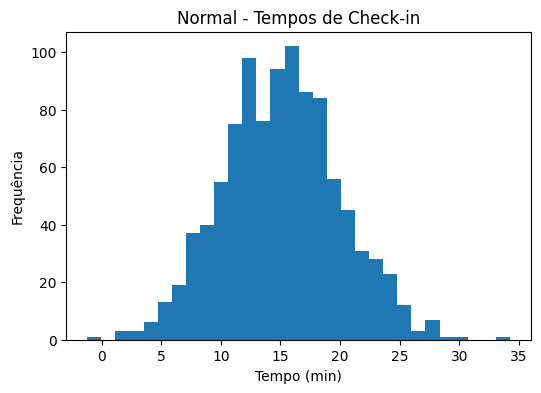

Média: 15.096660279111628
Desvio padrão: 4.893631038736771
Probabilidade de tempo > 25 min: 0.02149947725581769


In [11]:
media = 15
desvio = 5

checkin = np.random.normal(media, desvio, 1000)

plt.figure(figsize=(6,4))
plt.hist(checkin, bins=30)
plt.title("Normal - Tempos de Check-in")
plt.xlabel("Tempo (min)")
plt.ylabel("Frequência")
plt.show()

print("Média:", np.mean(checkin))
print("Desvio padrão:", np.std(checkin))

prob_extremo = 1 - stats.norm.cdf(25, np.mean(checkin), np.std(checkin))
print("Probabilidade de tempo > 25 min:", prob_extremo)


## Distribuição de Poisson – Aterrissagens de Emergência

Aterrissagens de emergência são eventos raros que ocorrem ao longo do tempo.
Vamos modelar a quantidade desses eventos utilizando a distribuição de Poisson.


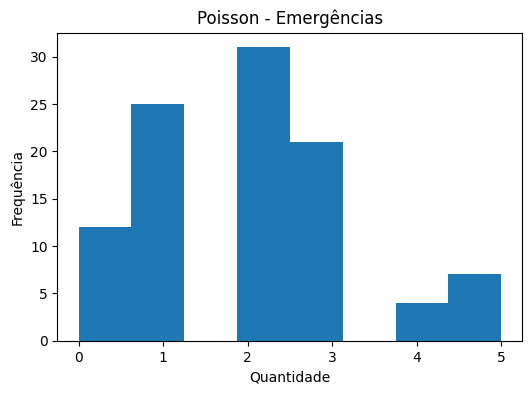

Probabilidade de 5 emergências: 0.03608940886309672


In [12]:
lambda_emerg = 2
emergencias = np.random.poisson(lambda_emerg, 100)

plt.figure(figsize=(6,4))
plt.hist(emergencias, bins=8)
plt.title("Poisson - Emergências")
plt.xlabel("Quantidade")
plt.ylabel("Frequência")
plt.show()

prob_5 = stats.poisson.pmf(5, lambda_emerg)
print("Probabilidade de 5 emergências:", prob_5)


## Distribuição Binomial – Detecção de Ameaças

Cada inspeção de segurança pode resultar em sucesso ou falha.
Vamos utilizar a distribuição binomial para simular o número de ameaças detectadas em um conjunto de inspeções.


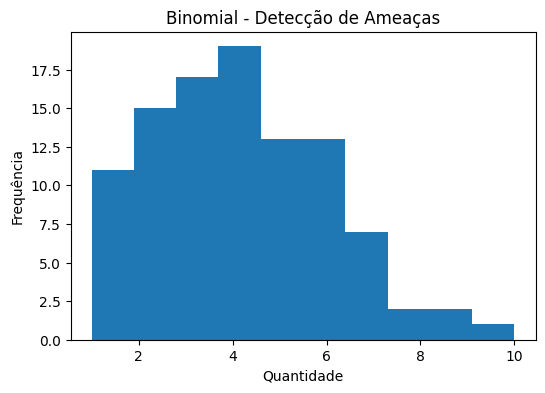

Probabilidade de detectar 3 ameaças: 0.19634683738879807


In [13]:
n = 200
p = 0.02

deteccoes = np.random.binomial(n, p, size=100)

plt.figure(figsize=(6,4))
plt.hist(deteccoes, bins=10)
plt.title("Binomial - Detecção de Ameaças")
plt.xlabel("Quantidade")
plt.ylabel("Frequência")
plt.show()

prob_3 = stats.binom.pmf(3, n, p)
print("Probabilidade de detectar 3 ameaças:", prob_3)


## Distribuição Bernoulli – Direcionamento de Bagagens

Cada bagagem pode ser direcionada corretamente ou incorretamente.
Vamos modelar esse processo como um experimento de Bernoulli para avaliar a eficiência do sistema.


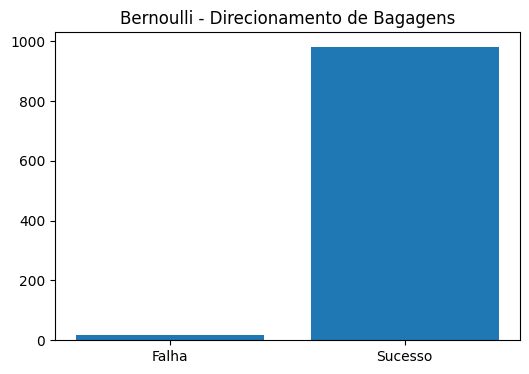

Taxa de acerto: 0.981


In [14]:
p_correto = 0.98
bagagens = stats.bernoulli.rvs(p_correto, size=1000)

plt.figure(figsize=(6,4))
plt.bar(["Falha", "Sucesso"],
        [np.sum(bagagens==0), np.sum(bagagens==1)])
plt.title("Bernoulli - Direcionamento de Bagagens")
plt.show()

print("Taxa de acerto:", np.mean(bagagens))


## Distribuição Multinomial – Alocação de Portões

Os voos podem ser distribuídos entre diferentes portões de embarque.
Vamos utilizar a distribuição multinomial para simular essa alocação.


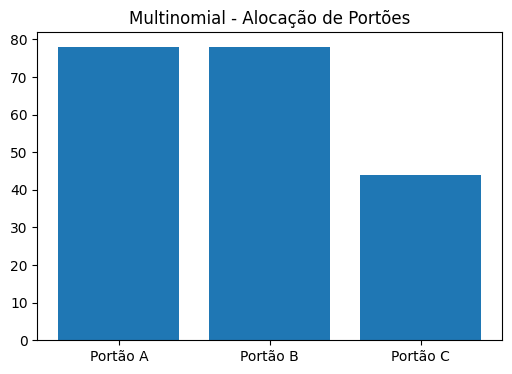

Distribuição dos voos: [78 78 44]


In [15]:
voos = 200
prob_portoes = [0.4, 0.35, 0.25]

portoes = np.random.multinomial(voos, prob_portoes)

plt.figure(figsize=(6,4))
plt.bar(["Portão A", "Portão B", "Portão C"], portoes)
plt.title("Multinomial - Alocação de Portões")
plt.show()

print("Distribuição dos voos:", portoes)


## Distribuição Geométrica – Primeira Falha do Sistema

O tempo até a primeira falha do sistema de bagagens é incerto.
Vamos utilizar a distribuição geométrica para estimar o número de dias até a primeira falha.


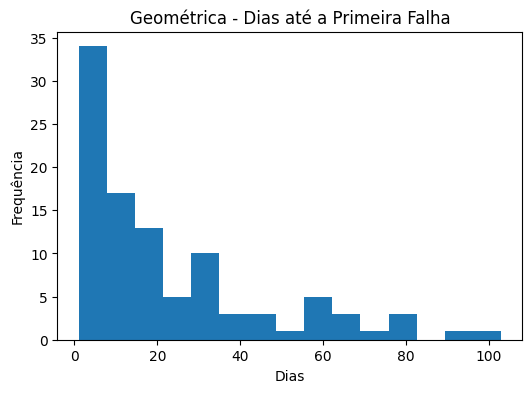

Média de dias até falha: 22.72


In [16]:
p_falha = 0.05
falhas = np.random.geometric(p_falha, size=100)

plt.figure(figsize=(6,4))
plt.hist(falhas, bins=15)
plt.title("Geométrica - Dias até a Primeira Falha")
plt.xlabel("Dias")
plt.ylabel("Frequência")
plt.show()

print("Média de dias até falha:", np.mean(falhas))


## Conclusão

A aplicação de distribuições probabilísticas permitiu modelar diferentes aspectos das operações aeroportuárias.

Os resultados demonstram como a estatística pode apoiar a gestão operacional:

- A distribuição normal permitiu avaliar o desempenho do processo de check-in.
- A distribuição de Poisson ajudou a analisar eventos raros, como emergências.
- A distribuição binomial possibilitou avaliar a eficiência das inspeções de segurança.
- A distribuição de Bernoulli permitiu medir a qualidade do direcionamento de bagagens.
- A distribuição multinomial mostrou a utilização dos portões de embarque.
- A distribuição geométrica ajudou a estimar a confiabilidade do sistema de bagagens.

Essas análises permitem prever cenários, identificar riscos e apoiar decisões estratégicas, contribuindo para maior eficiência operacional, melhor alocação de recursos e melhoria da qualidade dos serviços prestados pelo aeroporto.
